In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# Install required packages
!pip install -q thop torchmetrics scikit-learn seaborn pandas matplotlib

**Import Required Libraries**

In [2]:
import os
import time
import copy
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from thop import profile

warnings.filterwarnings("ignore")

**Set Random Seed and Device**

In [3]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU Name: Tesla T4


**Dataset Path Setup**

In [4]:
DATASET_ROOT = "/kaggle/input/datasets/diptadasopu/processed-rice-varieties-of-bangladesh/PRBD Microscopic Image of Different Processed Rice/Original_Images"   # Change this if needed

def find_imagefolder_root(root_dir):
    """
    Find a folder that looks like a torchvision ImageFolder root:
    direct child folders = class folders containing images
    """
    root_dir = Path(root_dir)
    if not root_dir.exists():
        raise FileNotFoundError(f"Dataset root not found: {root_dir}")

    image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

    # Case 1: root itself already ImageFolder root
    subdirs = [p for p in root_dir.iterdir() if p.is_dir()]
    if subdirs:
        valid_class_dirs = 0
        for d in subdirs:
            if any(f.suffix.lower() in image_exts for f in d.rglob("*") if f.is_file()):
                valid_class_dirs += 1
        if valid_class_dirs >= 2:
            return str(root_dir)

    # Case 2: search deeper
    for candidate in root_dir.rglob("*"):
        if candidate.is_dir():
            subdirs = [p for p in candidate.iterdir() if p.is_dir()]
            if len(subdirs) >= 2:
                valid_class_dirs = 0
                for d in subdirs:
                    if any(f.suffix.lower() in image_exts for f in d.rglob("*") if f.is_file()):
                        valid_class_dirs += 1
                if valid_class_dirs >= 2:
                    return str(candidate)

    raise RuntimeError(
        "Could not automatically find an ImageFolder-compatible root. "
        "Please set DATASET_ROOT directly to the folder whose immediate subfolders are the classes."
    )

data_dir = find_imagefolder_root(DATASET_ROOT)
print("ImageFolder root found at:", data_dir)

ImageFolder root found at: /kaggle/input/datasets/diptadasopu/processed-rice-varieties-of-bangladesh/PRBD Microscopic Image of Different Processed Rice/Original_Images


**Define Hyperparameters and Image Transforms**

In [5]:
INPUT_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
TEST_RATIO = 0.10
VAL_RATIO_WITHIN_TRAIN = 0.10

train_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

****

In [6]:
base_dataset = datasets.ImageFolder(data_dir)
class_names = base_dataset.classes
num_classes = len(class_names)

all_indices = np.arange(len(base_dataset))
all_labels = np.array(base_dataset.targets)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Total images:", len(base_dataset))

Classes: ['Aush', 'BR-28', 'BR-29', 'Beroi', 'Chinigura', 'Ghee Bhog', 'Katari Najir', 'Katari Siddho', 'Miniket', 'Swarna']
Number of classes: 10
Total images: 2000


**Create Fixed 90:10 Split**

In [8]:
train_val_indices, test_indices = train_test_split(
    all_indices,
    test_size=TEST_RATIO,
    stratify=all_labels,
    random_state=SEED,
    shuffle=True
)

train_val_labels = all_labels[train_val_indices]

train_indices, val_indices = train_test_split(
    train_val_indices,
    test_size=VAL_RATIO_WITHIN_TRAIN,
    stratify=train_val_labels,
    random_state=SEED,
    shuffle=True
)

print(f"Train+Val size: {len(train_val_indices)}")
print(f"Test size     : {len(test_indices)}")
print(f"Train size    : {len(train_indices)}")
print(f"Val size      : {len(val_indices)}")

print(f"Effective Train Ratio: {len(train_indices)/len(base_dataset):.4f}")
print(f"Effective Val Ratio  : {len(val_indices)/len(base_dataset):.4f}")
print(f"Effective Test Ratio : {len(test_indices)/len(base_dataset):.4f}")

Train+Val size: 1800
Test size     : 200
Train size    : 1620
Val size      : 180
Effective Train Ratio: 0.8100
Effective Val Ratio  : 0.0900
Effective Test Ratio : 0.1000


**Build Dataset Subsets and DataLoaders**

In [10]:
class TransformSubset(Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y = self.dataset[self.indices[idx]]
        if self.transform is not None:
            x = self.transform(x)
        return x, y

train_dataset = TransformSubset(base_dataset, train_indices, transform=train_transform)
val_dataset   = TransformSubset(base_dataset, val_indices, transform=eval_transform)
test_dataset  = TransformSubset(base_dataset, test_indices, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

**Check Class Distribution Across Splits**

In [12]:
def count_labels(indices, labels, class_names):
    counts = pd.Series(labels[indices]).value_counts().sort_index()
    counts.index = [class_names[i] for i in counts.index]
    return counts

split_df = pd.DataFrame({
    "Train": count_labels(train_indices, all_labels, class_names),
    "Val": count_labels(val_indices, all_labels, class_names),
    "Test": count_labels(test_indices, all_labels, class_names),
}).fillna(0).astype(int)

display(split_df)

,Train,Val,Test
Aush,162,18,20
BR-28,162,18,20
BR-29,162,18,20
Beroi,162,18,20
Chinigura,162,18,20
Ghee Bhog,162,18,20
Katari Najir,162,18,20
Katari Siddho,162,18,20
Miniket,162,18,20
Swarna,162,18,20


**Define EfficientNet-B0 Model**

In [13]:
def get_efficientnet_b0(num_classes):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model = models.efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

def calculate_gflops(model, input_size=(1, 3, 224, 224)):
    model.eval()
    cpu_device = torch.device("cpu")
    model_cpu = copy.deepcopy(model).to(cpu_device)
    dummy_input = torch.randn(input_size).to(cpu_device)
    macs, _ = profile(model_cpu, inputs=(dummy_input,), verbose=False)
    return macs / 1e9

model = get_efficientnet_b0(num_classes)
gflops = calculate_gflops(model, input_size=(1, 3, INPUT_SIZE, INPUT_SIZE))
print(f"EfficientNet-B0 GFLOPs @ {INPUT_SIZE}x{INPUT_SIZE}: {gflops:.3f}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 132MB/s] 


EfficientNet-B0 GFLOPs @ 224x224: 0.414


**Define Training Function**

In [21]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=None,
    min_epochs=50,
    max_epochs=100,
    plateau_patience=10,
    min_delta=1e-4
):
    model = model.to(device)
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    best_val_loss = float("inf")

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    epochs_no_improve = 0
    start_time = time.time()

    for epoch in range(max_epochs):
        print(f"\nEpoch {epoch+1}/{max_epochs}")

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
                loader = train_loader
            else:
                model.eval()
                loader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in loader:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(loader.dataset)
            epoch_acc = running_corrects.double().item() / len(loader.dataset)

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            if phase == "train":
                print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")
            else:
                print(f"Val Loss  : {epoch_loss:.4f} | Val Acc  : {epoch_acc:.4f}")

                improved = False
                if epoch_acc > best_val_acc + min_delta:
                    improved = True
                elif abs(epoch_acc - best_val_acc) <= min_delta and epoch_loss < best_val_loss:
                    improved = True

                if improved:
                    best_val_acc = epoch_acc
                    best_val_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1

        if scheduler is not None:
            scheduler.step(history["val_loss"][-1])

        if (epoch + 1) >= min_epochs and epochs_no_improve >= plateau_patience:
            print(f"\nPlateau detected. Early stopping at epoch {epoch+1}.")
            break

    total_train_time = time.time() - start_time
    model.load_state_dict(best_model_wts)
    return model, history, total_train_time

**Define Evaluation Function**

In [22]:
def evaluate_and_plot(model, test_loader, class_names):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    start_time = time.time()

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device, non_blocking=True)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    test_time = time.time() - start_time

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    unique_test_classes = np.unique(all_labels)
    if len(unique_test_classes) > 1:
        labels_bin = label_binarize(all_labels, classes=np.arange(len(class_names)))
        if len(class_names) == 2:
            roc_auc = roc_auc_score(all_labels, all_probs[:, 1])
        else:
            roc_auc = roc_auc_score(labels_bin, all_probs, average="macro", multi_class="ovr")
    else:
        roc_auc = float("nan")

    cm = confusion_matrix(all_labels, all_preds, labels=np.arange(len(class_names)))
    per_class_acc = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)

    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)
    if cm_no_diag.sum() > 0:
        max_idx = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
        failure_mode = f"'{class_names[max_idx[0]]}' predicted as '{class_names[max_idx[1]]}' ({cm_no_diag[max_idx]} times)"
    else:
        failure_mode = "None"

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("EfficientNet-B0 - Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    if len(unique_test_classes) > 1:
        if len(class_names) == 2:
            fpr, tpr, _ = roc_curve(all_labels, all_probs[:, 1], pos_label=1)
            plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}")
        else:
            labels_bin = label_binarize(all_labels, classes=np.arange(len(class_names)))
            for i in range(len(class_names)):
                if np.sum(labels_bin[:, i]) > 0:
                    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
                    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={auc(fpr, tpr):.3f})")
        plt.legend(loc="lower right", fontsize=8)
    else:
        plt.text(0.5, 0.5, "ROC AUC unavailable\n(only one class in test set)",
                 ha="center", va="center")

    plt.plot([0, 1], [0, 1], "k--")
    plt.title("EfficientNet-B0 - ROC Curves")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.tight_layout()
    plt.show()

    return {
        "Model": "EfficientNet-B0",
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "Test_Time (s)": test_time,
        "Primary_Failure_Mode": failure_mode,
        "Per_Class_Acc": np.round(per_class_acc, 4).tolist()
    }

**Train the EfficientNet-B0 Model**

In [25]:
model = get_efficientnet_b0(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=4
)

trained_model, history, train_time = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    min_epochs=50,
    max_epochs=100,
    plateau_patience=10,
    min_delta=1e-4
)

print(f"\nTraining complete in {train_time:.2f} seconds")


Epoch 1/100
Train Loss: 1.6814 | Train Acc: 0.5574
Val Loss  : 0.7830 | Val Acc  : 0.7944

Epoch 2/100
Train Loss: 0.6277 | Train Acc: 0.8457
Val Loss  : 0.2915 | Val Acc  : 0.9278

Epoch 3/100
Train Loss: 0.3478 | Train Acc: 0.9006
Val Loss  : 0.2595 | Val Acc  : 0.8944

Epoch 4/100
Train Loss: 0.2657 | Train Acc: 0.9185
Val Loss  : 0.1727 | Val Acc  : 0.9667

Epoch 5/100
Train Loss: 0.2181 | Train Acc: 0.9253
Val Loss  : 0.1374 | Val Acc  : 0.9444

Epoch 6/100
Train Loss: 0.1743 | Train Acc: 0.9469
Val Loss  : 0.1585 | Val Acc  : 0.9389

Epoch 7/100
Train Loss: 0.1510 | Train Acc: 0.9531
Val Loss  : 0.1125 | Val Acc  : 0.9667

Epoch 8/100
Train Loss: 0.1623 | Train Acc: 0.9420
Val Loss  : 0.1457 | Val Acc  : 0.9500

Epoch 9/100
Train Loss: 0.1300 | Train Acc: 0.9512
Val Loss  : 0.1189 | Val Acc  : 0.9556

Epoch 10/100
Train Loss: 0.1124 | Train Acc: 0.9636
Val Loss  : 0.1190 | Val Acc  : 0.9500

Epoch 11/100
Train Loss: 0.0948 | Train Acc: 0.9722
Val Loss  : 0.1320 | Val Acc  : 0.95

**Plot Training and Validation Curves**

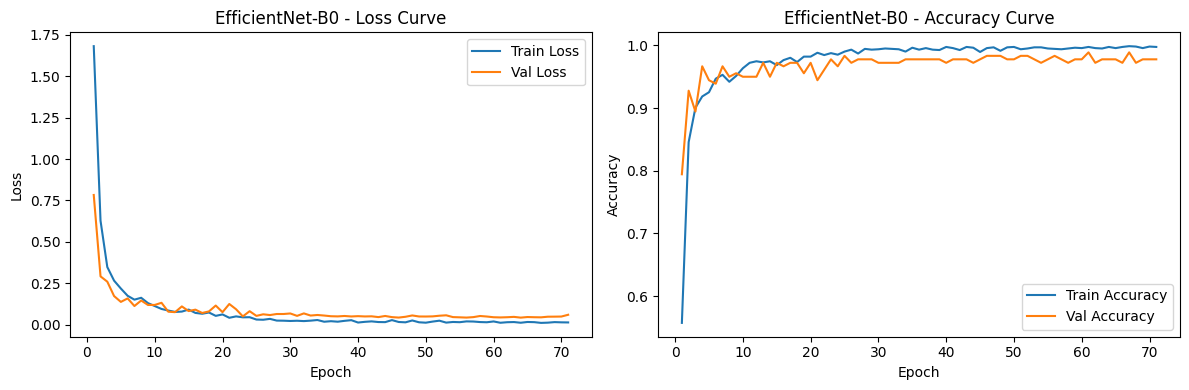

In [26]:
epochs_ran = len(history["train_loss"])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs_ran + 1), history["train_loss"], label="Train Loss")
plt.plot(range(1, epochs_ran + 1), history["val_loss"], label="Val Loss")
plt.title("EfficientNet-B0 - Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs_ran + 1), history["train_acc"], label="Train Accuracy")
plt.plot(range(1, epochs_ran + 1), history["val_acc"], label="Val Accuracy")
plt.title("EfficientNet-B0 - Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

**Final Evaluation on Test Set**

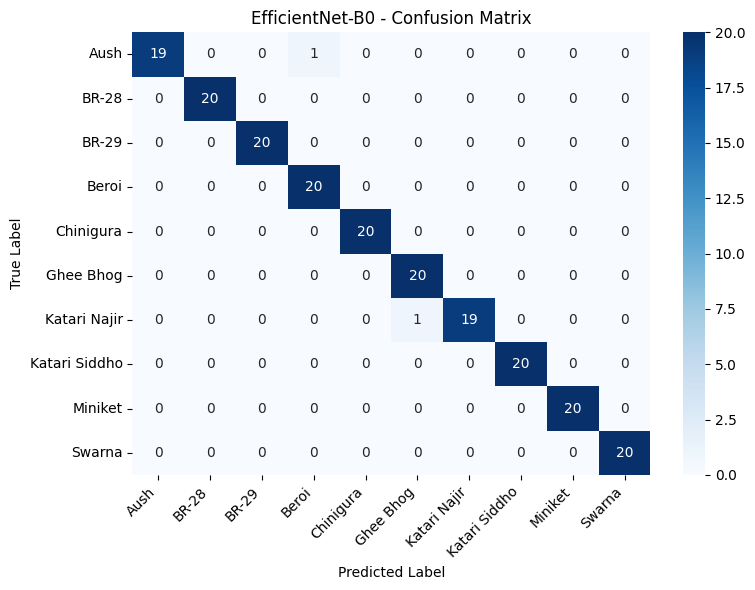

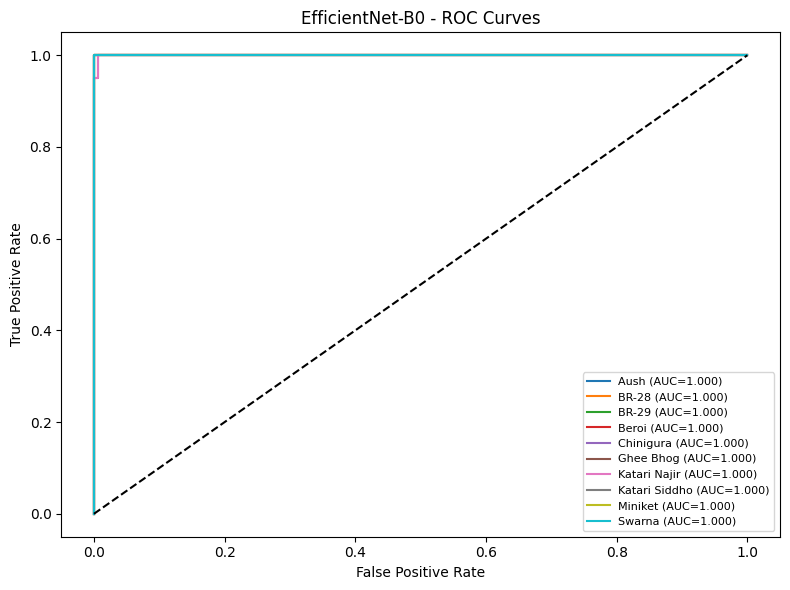

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,GFLOPs (224x224),Train_Time (s),Test_Time (s),Primary_Failure_Mode
0,EfficientNet-B0,0.99,0.9905,0.99,0.99,0.9999,0.4139,1056.8668,1.9215,'Aush' predicted as 'Beroi' (1 times)


Per-class accuracy: [0.95, 1.0, 1.0, 1.0, 1.0, 1.0, 0.95, 1.0, 1.0, 1.0]


In [27]:
metrics = evaluate_and_plot(trained_model, test_loader, class_names)
metrics["Train_Time (s)"] = train_time
metrics["GFLOPs (224x224)"] = gflops

results_df = pd.DataFrame([metrics])[[
    "Model", "Accuracy", "Precision", "Recall", "F1-Score",
    "ROC-AUC", "GFLOPs (224x224)", "Train_Time (s)",
    "Test_Time (s)", "Primary_Failure_Mode"
]]

display(results_df.round(4))
print("Per-class accuracy:", metrics["Per_Class_Acc"])

In [29]:
torch.save(trained_model.state_dict(), "efficientnet_90_10.pth")
print("Model saved as efficientnet_90_10.pth")

Model saved as efficientnet_90_10.pth
